> **Fork note (SJSU CMPE 295A G2, Jul 2026):** this copy adds *DUCK MODS v1* in section 6 (stall-restart + prompt addendum + exposed knobs). Everything else is unchanged from Tufa Labs' shared notebook. See `index.html` in the repo for the full analysis and submission playbook.

# Tufa Labs ARC3 submission

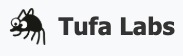

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [1]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

taaf.kaggle: TRUE_SUBMISSION=False


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [2]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

0

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [3]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

taaf.kaggle: source bundle = /kaggle/input/datasets/jeroencottaar/taaf-kaggle-source-share
taaf.kaggle: input paths = {"driessmit1/arc3-vllm-h100-wheelhouse-v3": "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot": "/kaggle/input/datasets/driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot", "jeroencottaar/taaf-kaggle-source-share": "/kaggle/input/datasets/jeroencottaar/taaf-kaggle-source-share"}


## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [4]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

taaf.kaggle: wrote /usr/local/lib/python3.12/dist-packages/taaf_kaggle_sources.pth (3 source roots)
taaf.kaggle: setup command: "$PYTHON" - <<'PYSETUP'
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'driessmit1'
MODEL_SLUG = 'vrfai-qwen3-6-27b-fp8-hf-snapshot'
SERVED_MODEL_NAME = 'vrfai/Qwen3.6-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-server.pid'
INSTALL_STAMP = SITE_PACKAGES / f'.{WHEELHOUSE_SLUG}'
STAMP_TEXT = 'vllm==0.19.0 torch==2.10.0 flashinfer==0.6.6\n'


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [5]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook — **DUCK MODS installed here**

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

**This copy installs "DUCK MODS v1" (SJSU CMPE 295A Group 2):**

1. **Stall restart** — if a game makes no level progress for 27 minutes, the agent's chat
   context is wiped so a fresh "brain" re-reads the board. Identical Duck submissions score
   0.77–1.30 because almost all points come from runs whose *early* hypotheses happen to be
   right (public-set per-pass median ≈ 0.1 vs mean 1.60); wiping a stuck context converts dead
   GPU time into up to 4 extra independent attempts per game. Completed levels stay banked.
2. **Prompt addendum** — tells the model that levels survive RESET, that score is
   (human/agent actions)², and to switch hypotheses instead of grinding a failing plan.
3. **Exposed knobs** — temperature / concurrency / per-game budget, all defaulting to the
   bundle's stock values (0.6 / 28 / 132 min).

All mods are defensive in-notebook monkeypatches: the Tufa datasets are used unmodified, and
any mod that fails simply leaves stock behavior in place. Set `DUCK_MODS["enabled"] = False`
to reproduce the stock 1.03 notebook exactly.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
#
# ==============================================================================
#  DUCK MODS v1 (SJSU CMPE 295A Group 2) - variance-harvesting upgrades
# ==============================================================================
#  Why: identical Duck submissions score anywhere between 0.77 and 1.30 on the
#  Kaggle leaderboard (Tufa Labs' own numbers), and on the 25 public games a
#  single pass has median ~0.1 vs mean 1.60 (+/-0.45). Nearly all of the score
#  comes from the minority of runs where the agent's early hypotheses happen to
#  be right. These mods convert dead time on stalled games into additional
#  independent attempts and add stall-recovery guidance to the system prompt.
#
#  Everything is an in-notebook monkeypatch: the attached Tufa datasets are
#  used unmodified, and every patch is defensive - if a patch fails, the stock
#  behavior is kept so a submission is never lost to a mod bug.

DUCK_MODS = {
    "enabled": True,

    # --- Mod 1: fresh-context restart of stalled games ------------------------
    # If a game shows no level progress for `stall_minutes`, wipe the agent's
    # chat context: a fresh "brain" re-reads the board without the bad priors
    # that got the previous attempt stuck. Completed levels are banked by the
    # scorecard and are NOT lost; the game itself is not reset.
    "enable_stall_restart": True,
    "stall_minutes": 27.0,          # allows ~4 fresh attempts in the 132-min budget
    "min_session_minutes": 6.0,     # never wipe a game in its first minutes
    "max_restarts_per_game": 4,
    "keep_world_model_on_restart": False,   # False = fully independent new draw

    # --- Mod 2: system-prompt addendum (stall recovery + scoring mechanics) ---
    "prompt_addendum": True,

    # --- Mod 3: knobs (None = keep the values pickled in the bundle) ----------
    "temperature": None,            # bundle default: 0.6
    "solver_concurrency": None,     # bundle default: 28 concurrent games
    "max_runtime_s_per_game": None, # bundle default: 7920 s (132 min per game)
    "max_actions_per_game": None,   # bundle default: unlimited
}


def _install_duck_mods(mods):
    import time as _time
    import traceback as _tb

    if not mods.get("enabled"):
        print("[duck-mods] disabled - stock Duck harness behavior", flush=True)
        return
    applied, failed = [], []

    try:
        import inference.agent.tool_agent as _ta
    except Exception:
        print("[duck-mods] cannot import tool_agent - no mods applied:\n" + _tb.format_exc(), flush=True)
        return

    # ---- Mod 2: system-prompt addendum --------------------------------------
    if mods.get("prompt_addendum"):
        try:
            _addendum = (
                "\n\nStall recovery and scoring mechanics:\n"
                "- The per-level score is (human_actions / your_actions)^2, so wasted actions are punished "
                "quadratically. Completing a new level is worth far more than polishing an old one, and "
                "levels already completed stay completed even after RESET.\n"
                "- If many turns pass with no level completion, treat your current theory of the game as "
                "probably wrong: write down 2-3 alternative interpretations of the mechanics and run the "
                "cheapest discriminating probe, instead of repeating variations of the same failing plan.\n"
                "- If the level looks unwinnable from the current position, or you have already spent a very "
                "large number of actions on it, RESET the level and execute your best-known route efficiently.\n"
            )
            if hasattr(_ta, "PYTHON_ADDENDUM") and _addendum not in _ta.PYTHON_ADDENDUM:
                _ta.PYTHON_ADDENDUM = _ta.PYTHON_ADDENDUM + _addendum
                applied.append("prompt_addendum")
        except Exception:
            failed.append("prompt_addendum")
            print(_tb.format_exc(), flush=True)

    # ---- Mod 3a: sampling temperature ----------------------------------------
    try:
        if mods.get("temperature") is not None:
            _ta._LOCAL_ANALYZER_TEMPERATURE = float(mods["temperature"])
            applied.append("temperature=%g" % mods["temperature"])
    except Exception:
        failed.append("temperature")
        print(_tb.format_exc(), flush=True)

    # ---- Mod 3b: solver knobs -------------------------------------------------
    for _key, _attr, _cast in (
        ("solver_concurrency", "concurrency", int),
        ("max_runtime_s_per_game", "max_runtime_s_per_game", float),
        ("max_actions_per_game", "max_actions_per_game", int),
    ):
        try:
            if mods.get(_key) is not None:
                setattr(bm.solver, _attr, _cast(mods[_key]))
                applied.append("%s=%s" % (_attr, mods[_key]))
        except Exception:
            failed.append(_key)
            print(_tb.format_exc(), flush=True)

    # ---- Mod 1: fresh-context restart on stall --------------------------------
    if mods.get("enable_stall_restart"):
        try:
            if getattr(_ta.ToolAgent, "_duck_mods_patched", False):
                applied.append("stall_restart(already patched)")
            else:
                _orig_analyze = _ta.ToolAgent.analyze
                _trackers = {}
                _stall_s = float(mods["stall_minutes"]) * 60.0
                _warmup_s = float(mods["min_session_minutes"]) * 60.0
                _max_restarts = int(mods["max_restarts_per_game"])
                _keep_wm = bool(mods["keep_world_model_on_restart"])

                def _analyze_with_restarts(self, state_path, action_num, **kwargs):
                    key = None
                    try:
                        key = str(state_path.parent)
                        now = _time.monotonic()
                        tr = _trackers.get(key)
                        if tr is None:
                            tr = _trackers[key] = {
                                "t0": now, "level": None, "t_prog": now, "restarts": 0,
                            }
                        if (
                            tr["restarts"] < _max_restarts
                            and (now - tr["t0"]) >= _warmup_s
                            and (now - tr["t_prog"]) >= _stall_s
                            and self._history_messages
                        ):
                            self._history_messages = []
                            self._last_step_summary = None
                            if not _keep_wm:
                                try:
                                    self._summarized_knowledge = _ta._empty_world_model()
                                except Exception:
                                    pass
                            tr["restarts"] += 1
                            tr["t_prog"] = now
                            print(
                                "[duck-mods] %s: fresh-context restart #%d after %.0f min without level progress"
                                % (state_path.parent.name, tr["restarts"], _stall_s / 60.0),
                                flush=True,
                            )
                    except Exception:
                        print("[duck-mods] restart check failed:\n" + _tb.format_exc(), flush=True)

                    result = _orig_analyze(self, state_path, action_num, **kwargs)

                    try:
                        lar = getattr(self, "_last_action_result", None) or {}
                        lvl = lar.get("level")
                        tr = _trackers.get(key) if key is not None else None
                        if tr is not None and isinstance(lvl, int):
                            if tr["level"] is None or lvl > tr["level"]:
                                tr["level"] = lvl
                                tr["t_prog"] = _time.monotonic()
                    except Exception:
                        pass
                    return result

                _ta.ToolAgent.analyze = _analyze_with_restarts
                _ta.ToolAgent._duck_mods_patched = True
                applied.append(
                    "stall_restart(%gmin, warmup %gmin, max %d, keep_wm=%s)"
                    % (mods["stall_minutes"], mods["min_session_minutes"], _max_restarts, _keep_wm)
                )
        except Exception:
            failed.append("stall_restart")
            print(_tb.format_exc(), flush=True)

    print("[duck-mods] applied: %s | failed: %s" % (applied or "none", failed or "none"), flush=True)


_install_duck_mods(DUCK_MODS)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [7]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

benchmark.label : duck-harness-kaggle
benchmark.solver: HarnessSolver(label='duck-harness', runtime_environment=None, job_dir=None, soft_end_time=None, minimal_diagnostics=False, model='local', analyzer_timeout=900.0, max_actions_per_game=None, max_runtime_s_per_game=7920.0, concurrency=28, save_request_logs=False, start_local_server=False, local_server_config='', local_server_api_key_file='', local_server_repo_dir='/Users/jeroencottaar/code/ARC3-Inference', local_server_port=None, local_server_tensor_parallel_size=None, local_server_count=1, cancel_drain_timeout_s=120.0)
benchmark.passes: 1
benchmark.games : 25
git status:
  ARC3-Inference                   aa69123     DIRTY  add-kaggle-share-flag     Add flag to use shareable notebook
  tufa-arc-agi-framework           fe9f7c4     clean  submission-share-mode-bugfix  Fix dataset mapping, spell Isaiah's name properly
  re-arc-3                         57e46d619d  pinned  master                    (non-editable)
benchmark: regenerated 

analyzer request failed at action 27: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 4.75s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-07-01 15:06:28
ended:     in progress
mean score:    1.43
median score:  0.00
total actions: 1436
total tokens:  562701
generated tokens/sec: 186.58 (job wallclock)
total wallclock: 71317.9s

per-game (mean across passes):
  ar25-0c556536: score=0.00, levels=0.0/8, actions=46, tokens=22798
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=159, tokens=22928
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=24, tokens=23117
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=78, tokens=22587
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=23, tokens=22974
  ft09-0d8bbf25: score=14.29, levels=2.0/6, actions=26, tokens=16236
  g50t-5849a774: score=0.00, levels=0.0/7, actions=44, tokens=23058
  ka59-38d34dbb: score=0.00, levels=0.0/7, actions=20, tokens=20962
  lf52-271a04aa: score=1.82, levels=1.0/10, act

analyzer request failed at action 27: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 2.24s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-07-01 15:06:28
ended:     in progress
mean score:    1.67
median score:  0.00
total actions: 2154
total tokens:  795545
generated tokens/sec: 188.49 (job wallclock)
total wallclock: 99326.5s

per-game (mean across passes):
  ar25-0c556536: score=0.00, levels=0.0/8, actions=77, tokens=32750
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=231, tokens=32395
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=40, tokens=33674
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=207, tokens=33335
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=45, tokens=32898
  ft09-0d8bbf25: score=14.29, levels=2.0/6, actions=26, tokens=16236
  g50t-5849a774: score=0.00, levels=0.0/7, actions=93, tokens=33746
  ka59-38d34dbb: score=0.00, levels=0.0/7, actions=29, tokens=33546
  lf52-271a04aa: score=1.82, levels=1.0/10, ac

...

[finished] cn04-2fe56bfb state=gave_up level=1/6 score=4.76 actions=658 tokens=60023 per-level=24/29,634/54,0/85,0/300,0/208,0/113 note="tokens=60023"
[finished] ls20-9607627b state=gave_up level=1/7 score=0.98 actions=110 tokens=52872 per-level=42/22,68/123,0/73,0/84,0/96,0/192,0/186 note="tokens=57299"
[finished] bp35-0a0ad940 state=gave_up level=0/9 score=0.00 actions=451 tokens=61877 per-level=451/21,0/48,0/44,0/38,0/33,0/87,0/86,0/131,0/163 note="tokens=61877"
[finished] tr87-cd924810 state=gave_up level=0/6 score=0.00 actions=248 tokens=63753 per-level=248/54,0/58,0/40,0/45,0/71,0/146 note="tokens=64431"
[finished] lp85-305b61c3 state=gave_up level=1/8 score=2.78 actions=140 tokens=65224 per-level=5/17,135/38,0/31,0/16,0/41,0/60,0/26,0/159 note="tokens=65224"
[finished] su15-1944f8ab state=gave_up level=1/9 score=2.22 actions=131 tokens=66157 per-level=20/22,111/42,0/26,0/115,0/36,0/31,0/8,0/40,0/41 note="tokens=66157"


analyzer request failed at action 168: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=223.64177021600062)
analyzer request failed at action 135: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=131.13263458599977)
analyzer request failed at action 295: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=1.5735992459995032)
analyzer request failed at action 66: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=101.58743547200083)


[finished] g50t-5849a774 state=gave_up level=0/7 score=0.00 actions=167 tokens=63911 per-level=167/78,0/175,0/179,0/230,0/96,0/54,0/67 note="tokens=63911"
[finished] sb26-7fbdac44 state=gave_up level=1/8 score=1.44 actions=134 tokens=59922 per-level=25/18,109/28,0/18,0/19,0/31,0/23,0/58,0/18 note="tokens=64675"
[finished] vc33-5430563c state=gave_up level=2/7 score=4.54 actions=65 tokens=53014 per-level=7/7,49/18,9/44,0/61,0/131,0/34,0/152 note="tokens=65643"
[finished] sp80-589a99af state=gave_up level=1/6 score=0.08 actions=294 tokens=64025 per-level=294/39,0/58,0/25,0/148,0/96,0/152 note="tokens=64025"
[finished] m0r0-492f87ba state=gave_up level=0/6 score=0.00 actions=607 tokens=63820 per-level=607/30,0/111,0/203,0/26,0/500,0/237 note="tokens=63820"
[finished] r11l-495a7899 state=gave_up level=1/6 score=4.76 actions=81 tokens=56931 per-level=20/22,61/33,0/51,0/26,0/52,0/49 note="tokens=66201"
[finished] ar25-0c556536 state=gave_up level=1/8 score=0.31 actions=172 tokens=64211 per-l

analyzer request failed at action 89: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=113.31711688300038)


[finished] wa30-ee6fef47 state=gave_up level=0/9 score=0.00 actions=88 tokens=65363 per-level=88/71,0/119,0/183,0/98,0/368,0/68,0/79,0/442,0/415 note="tokens=65675"
benchmark: regenerated diagnostics in /kaggle/working in 5.73s
benchmark: duck-harness-kaggle
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-07-01 15:06:28
ended:     2026-07-01 17:19:14
duration:  2h 12m 46s
mean score:    2.21
median score:  0.08
total actions: 4896
total tokens:  1529985
generated tokens/sec: 192.05 (job wallclock)
total wallclock: 198110.7s

per-game (mean across passes):
  ar25-0c556536: score=0.31, levels=1.0/8, actions=172, tokens=64211
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=451, tokens=61877
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=99, tokens=64771
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=658, tokens=60023
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=111, tokens=66312
  ft09-0d8bbf25: score=26.07, levels=3.0/6, actions=

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



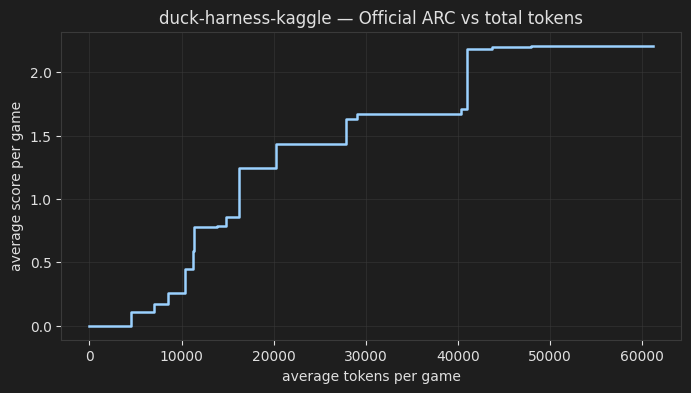
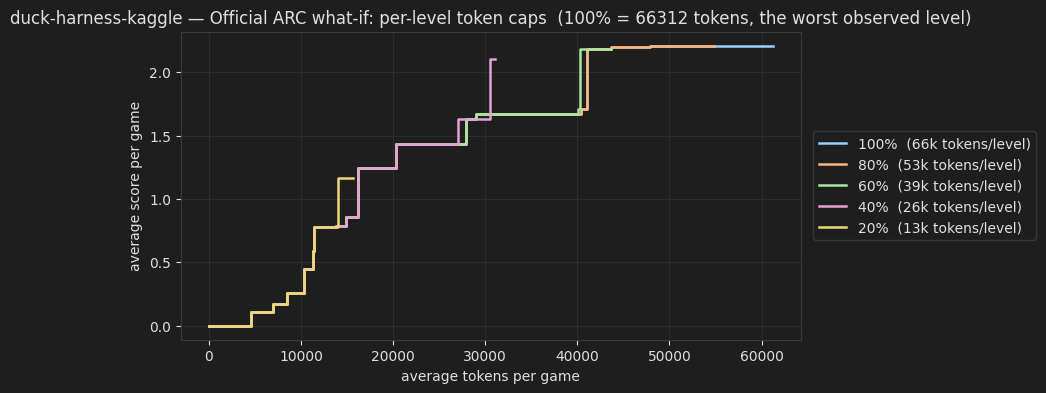
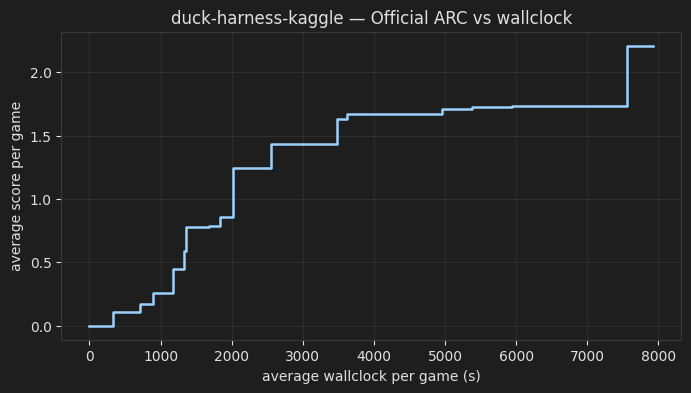
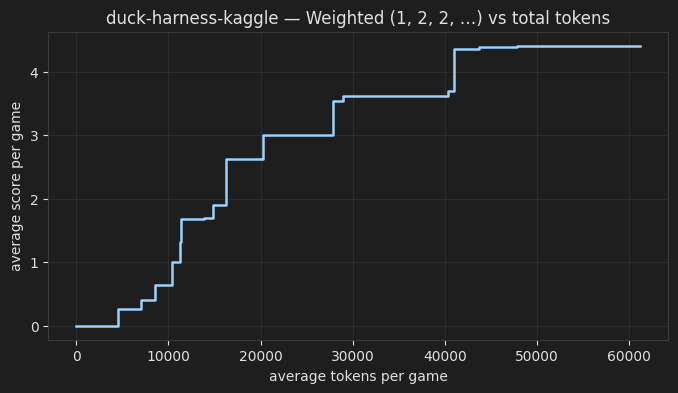
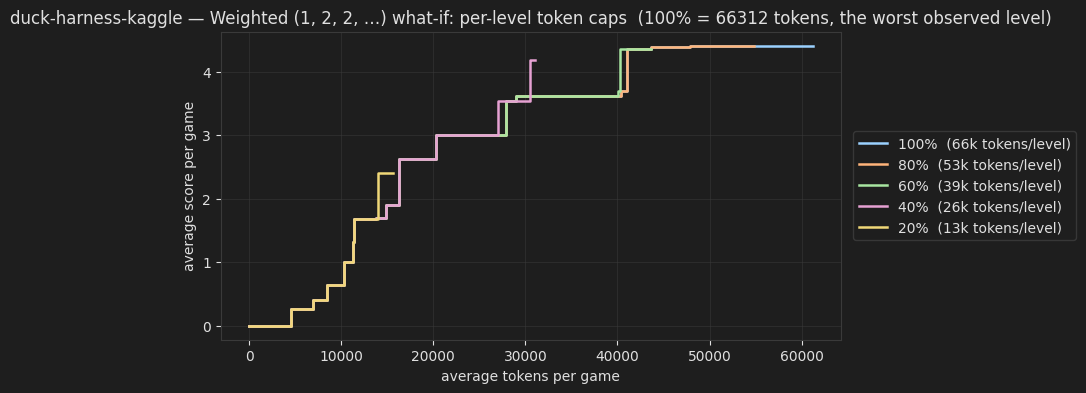
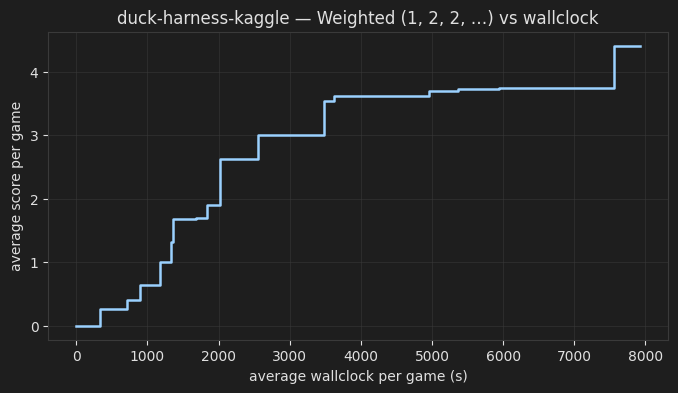
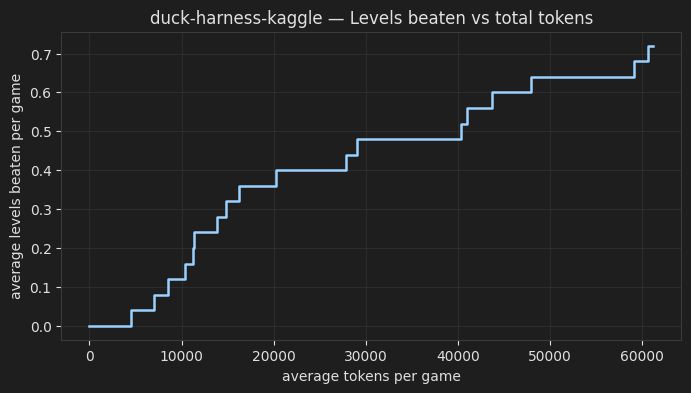
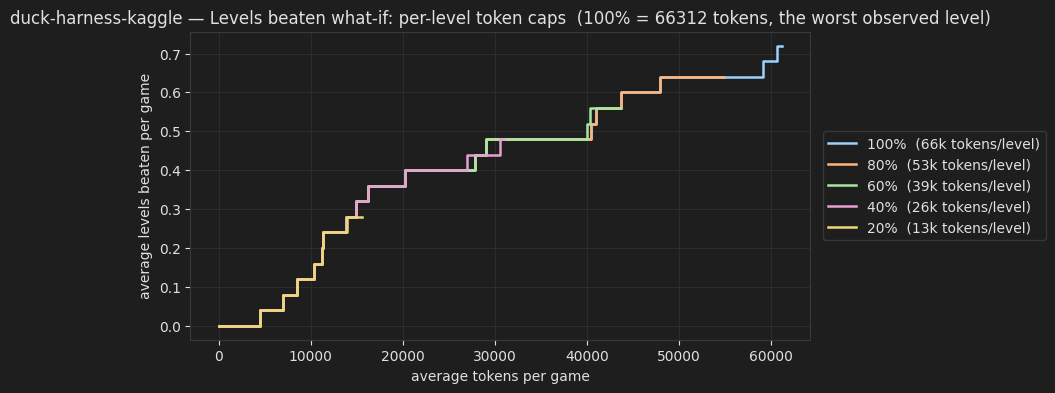
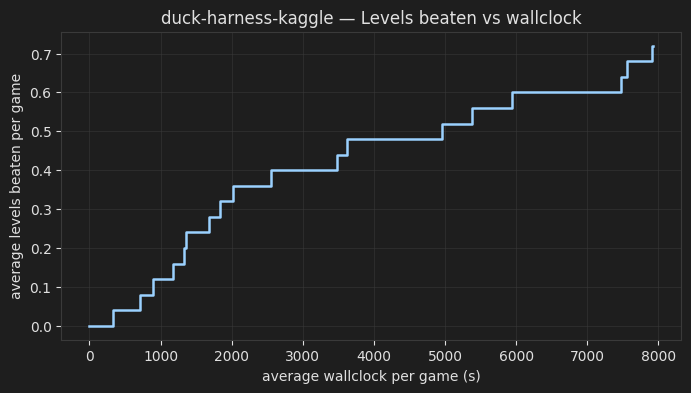
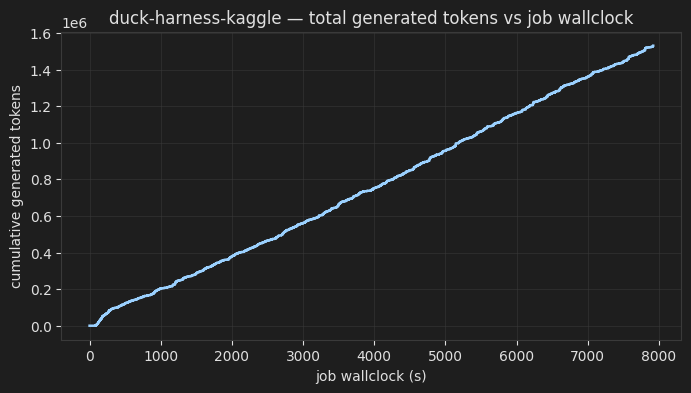
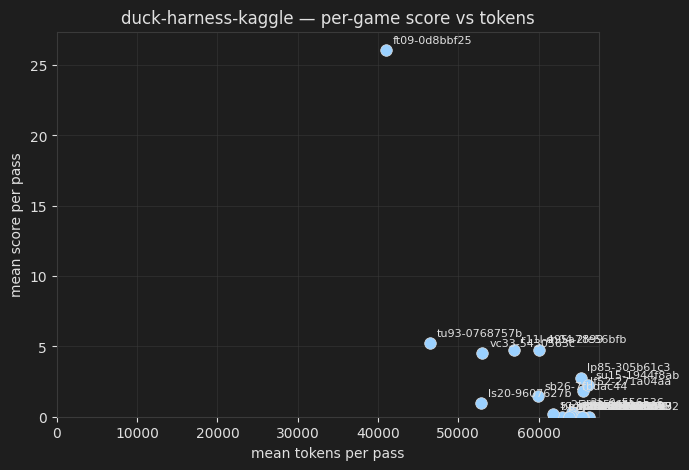
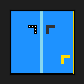
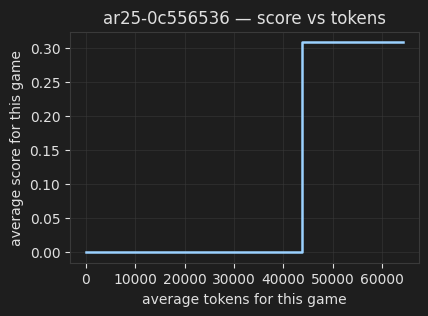
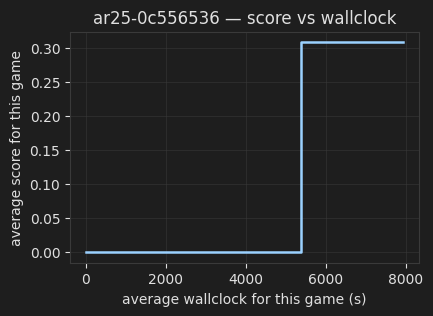
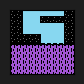
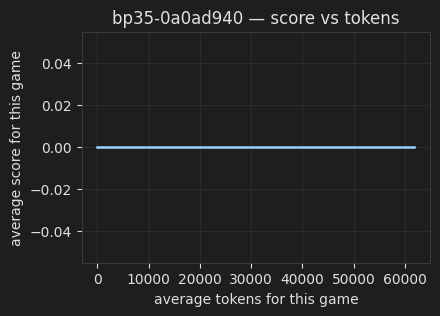
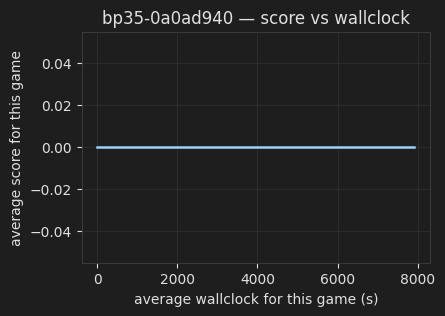
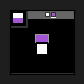
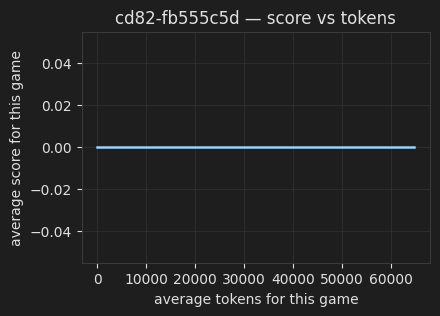
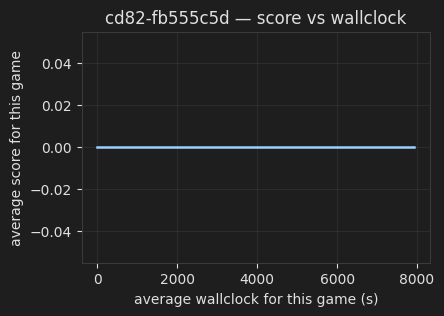
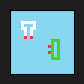
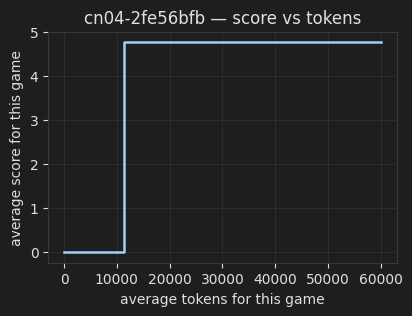
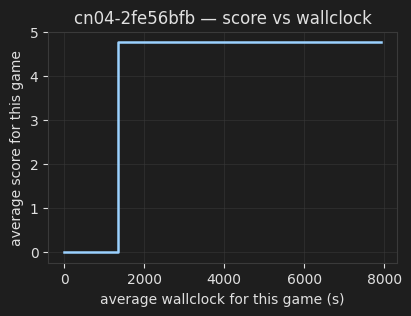
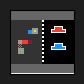
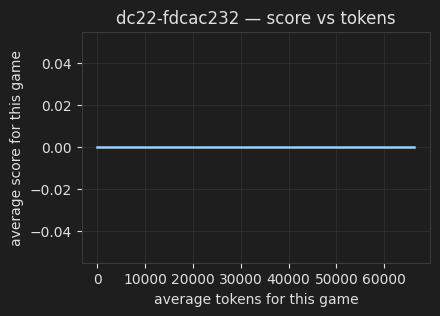
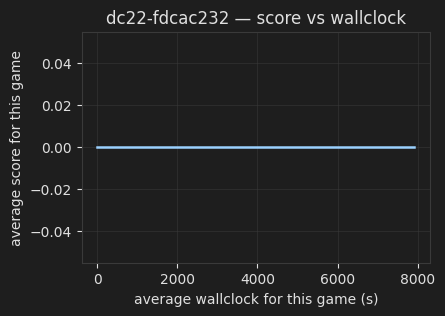
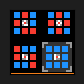
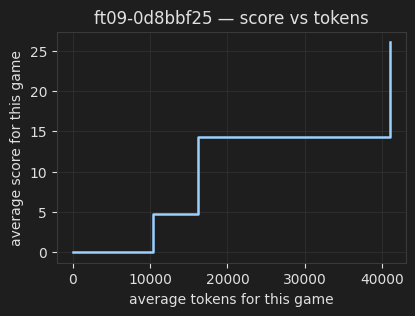
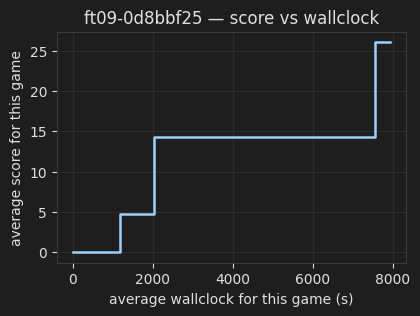
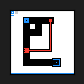
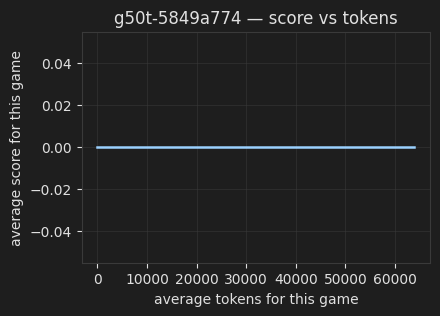
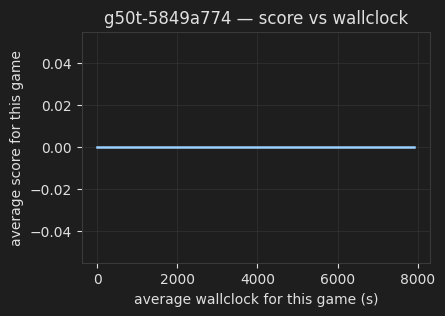
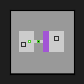
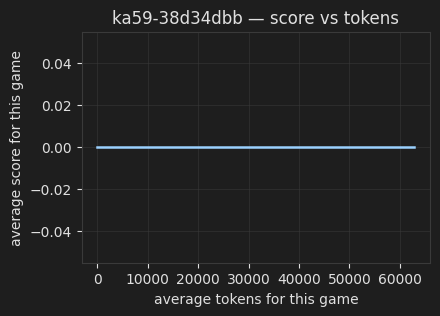
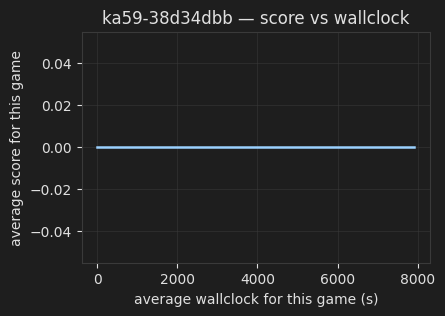
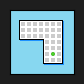
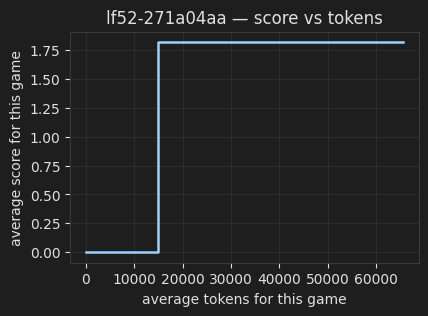
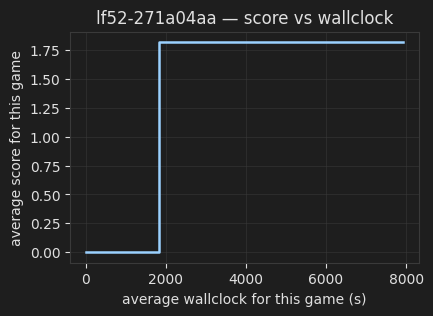
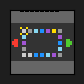
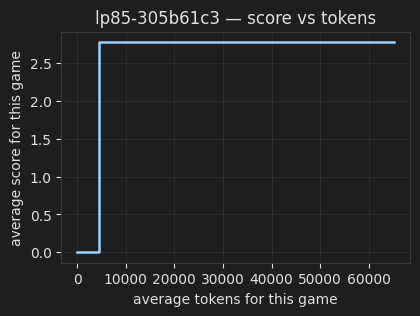
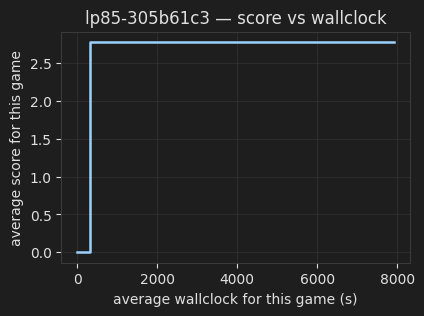
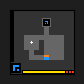
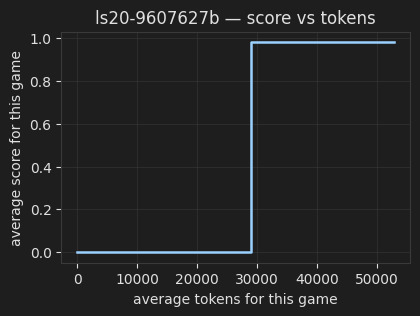
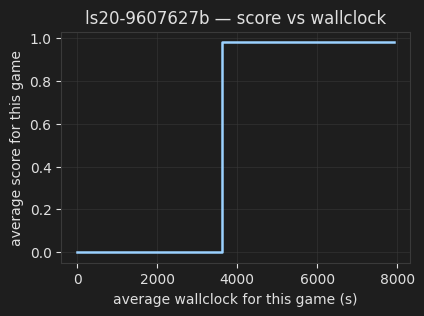
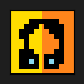
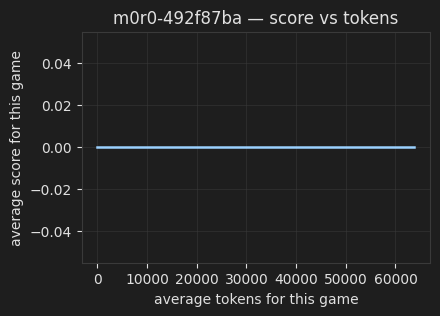
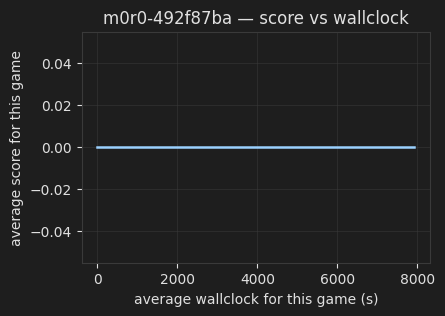
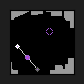
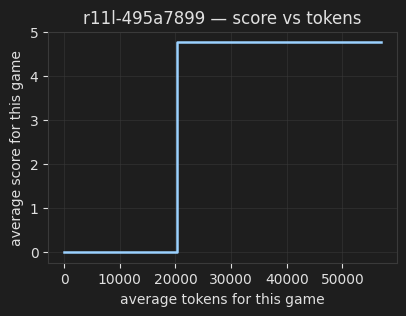
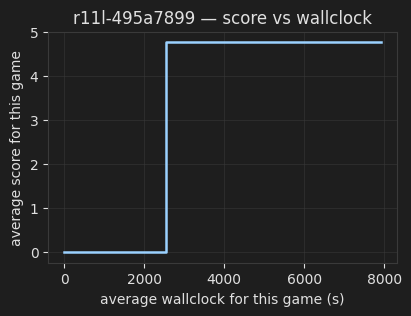
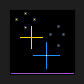
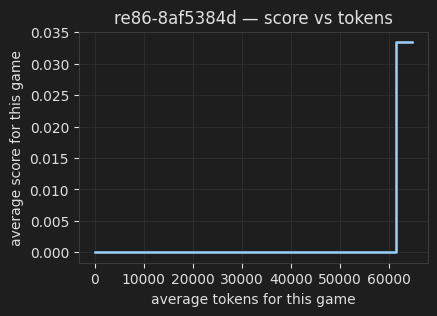
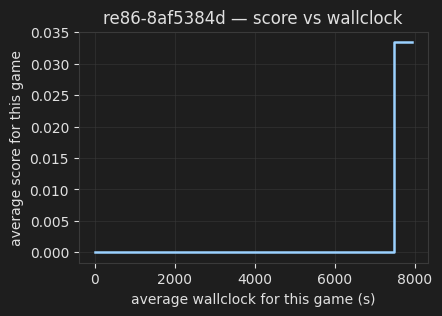
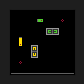
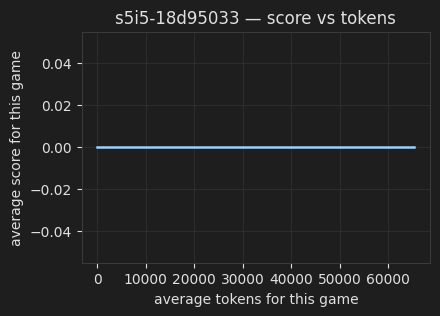
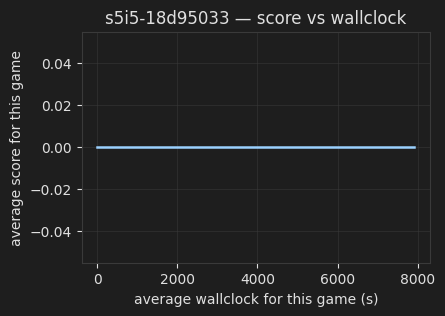
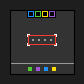
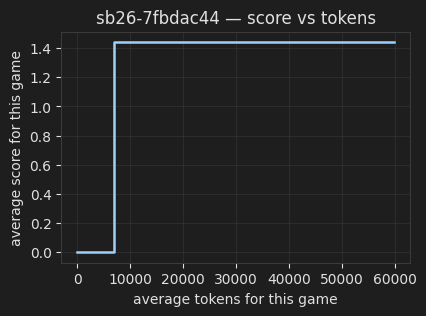
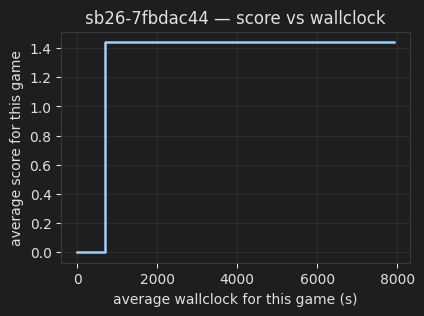
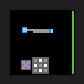
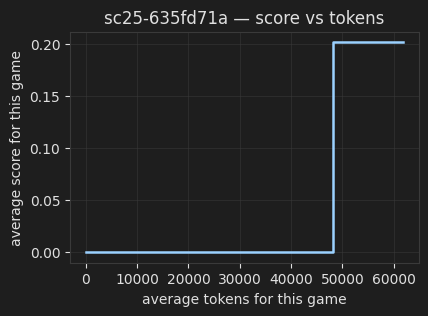
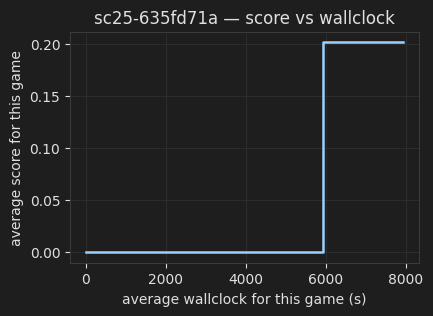
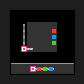
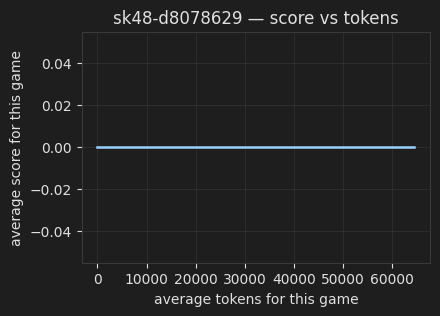
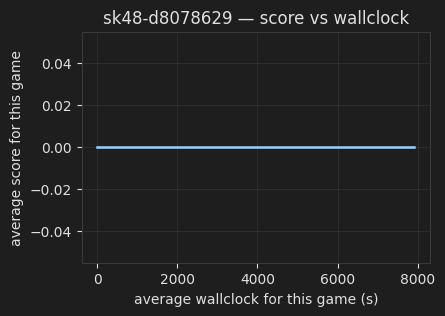
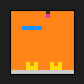
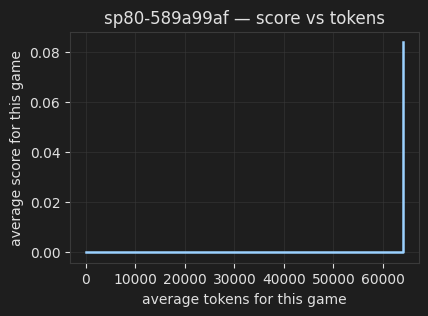
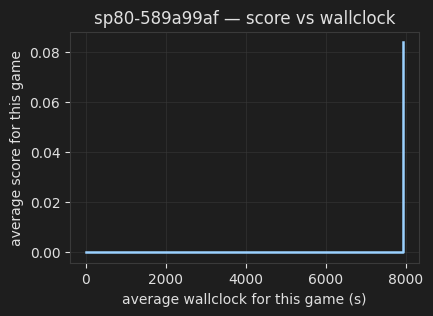
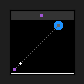
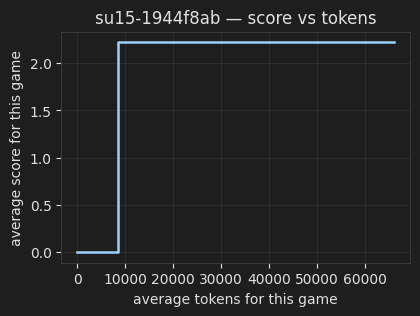
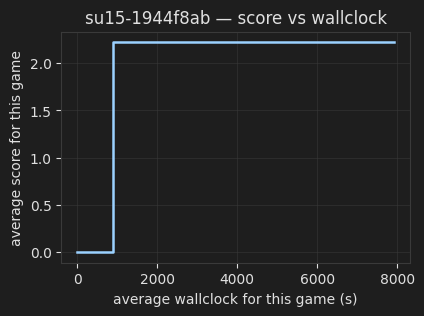
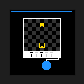
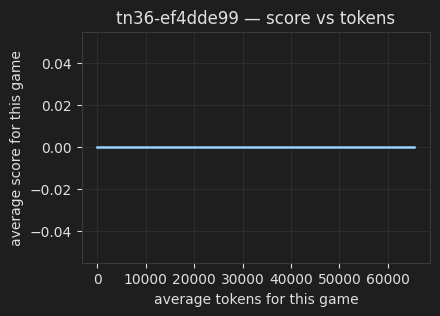
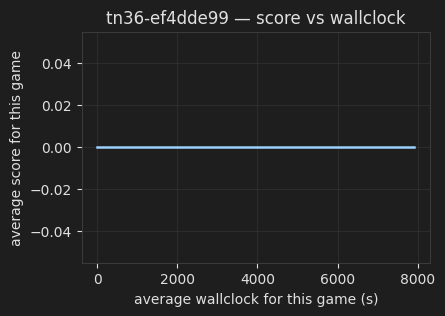
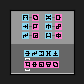
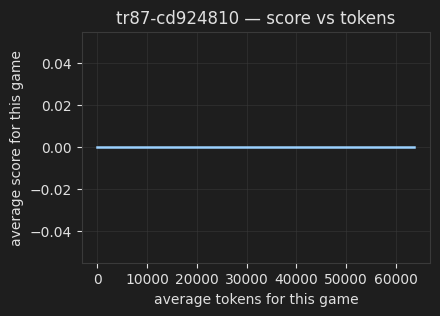
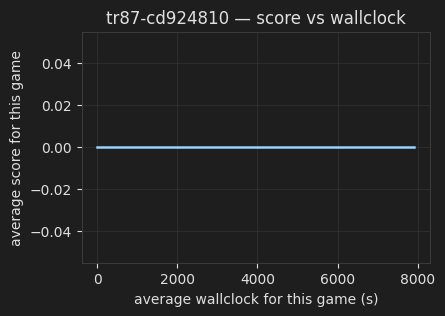
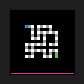
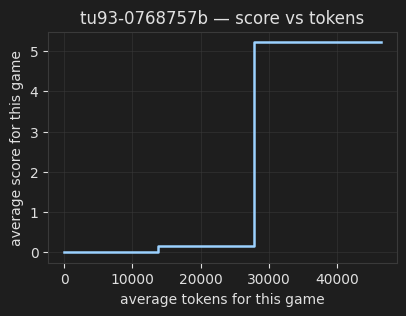
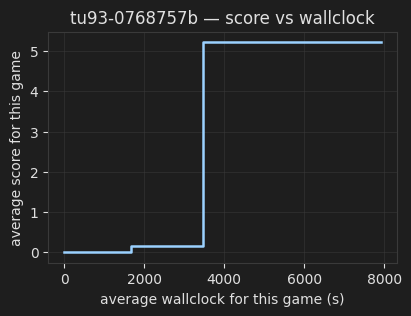
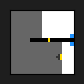
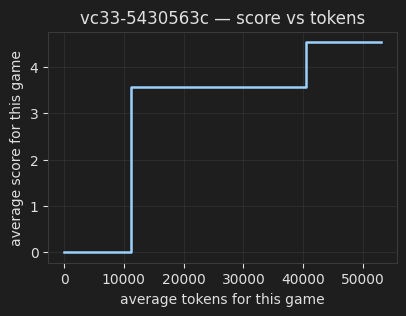
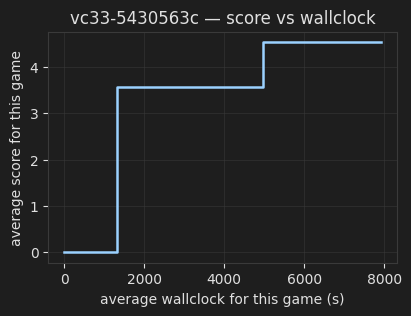
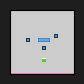
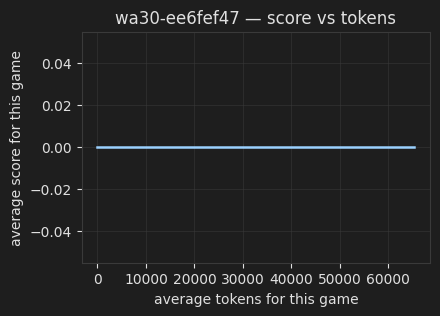
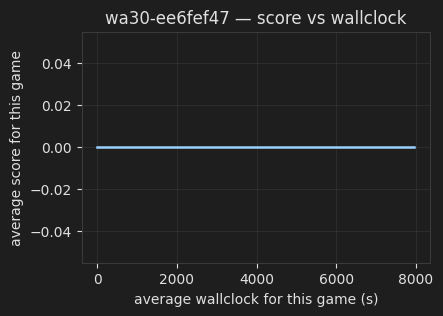
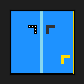
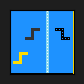
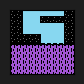
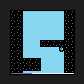
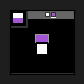
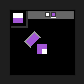
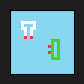
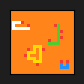
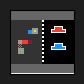
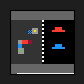
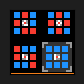
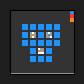
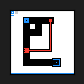
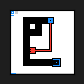
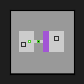
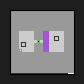
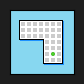
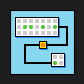
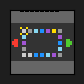
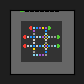
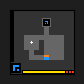
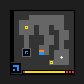
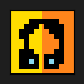
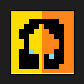
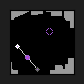
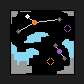
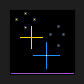
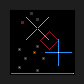
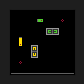
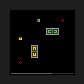
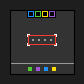
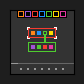
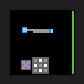
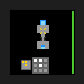
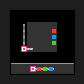
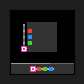
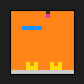
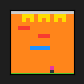
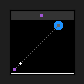
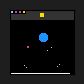
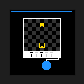
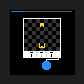
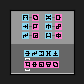
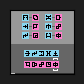
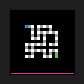
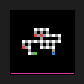
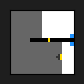
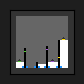
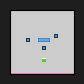
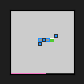

In [8]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")